# Train Synthetic, Test Real Evaluation


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
import umap

from core.data import load_dataset, split_dataset, BreathDataset
from models.vae import VAE, CVAE
from models.gan import CGAN #noqa

plt.rcParams.update({'legend.fontsize': 9,
                     'axes.titlesize': 10})

In [ ]:
# paths and params
RESULT_DIR = 'results'
SEEDS = [0, 1,7, 42, 123]
REGIONS = ['mouth', 'nose']
REGION_STYLE = {'mouth': '-', 'nose': '--'}
CLASSES = ['bradypnea', 'eupnea', 'tachypnea']
CLASS_COLORS = {'bradypnea': 'tab:blue', 'eupnea': 'tab:green', 'tachypnea': 'tab:purple'}
MODELS = ['trtr', 'cvae', 'vae', 'gan']
MODEL_COLOR = {'trtr': 'tab:blue', 'cvae': 'tab:green', 'vae': 'tab:orange', 'gan': 'tab:red'}
CHANNEL_NAMES = ['Humidity in %', 'Temperature in °C']
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')

model region      accuracy   f1_weighted   roc_auc_ovr      log_loss  f1_bradypnea     f1_eupnea  f1_tachypnea feature_overlap
 trtr  mouth 0.952 ± 0.041 0.952 ± 0.042 1.000 ± 0.000 0.177 ± 0.060 0.925 ± 0.066 0.963 ± 0.032 0.967 ± 0.029             nan
 cvae  mouth 0.857 ± 0.036 0.856 ± 0.037 0.947 ± 0.034 0.446 ± 0.105 0.888 ± 0.054 0.815 ± 0.046 0.864 ± 0.104   0.333 ± 0.058
  vae  mouth 0.405 ± 0.312 0.402 ± 0.314 0.552 ± 0.307 1.094 ± 0.124 0.426 ± 0.289 0.307 ± 0.295 0.465 ± 0.378   0.600 ± 0.000
  gan  mouth 0.464 ± 0.036 0.399 ± 0.085 0.676 ± 0.070 1.153 ± 0.083 0.375 ± 0.049 0.208 ± 0.240 0.592 ± 0.046   0.500 ± 0.100
 trtr   nose 0.772 ± 0.040 0.767 ± 0.042 0.923 ± 0.022 0.516 ± 0.072 0.869 ± 0.047 0.769 ± 0.067 0.655 ± 0.111             nan
 cvae   nose 0.588 ± 0.040 0.583 ± 0.055 0.711 ± 0.035 1.035 ± 0.094 0.624 ± 0.066 0.559 ± 0.225 0.563 ± 0.117   0.433 ± 0.115
  vae   nose 0.263 ± 0.091 0.254 ± 0.086 0.411 ± 0.074 1.152 ± 0.051 0.215 ± 0.158 0.366 ± 0.088 0.175 ± 0.161 

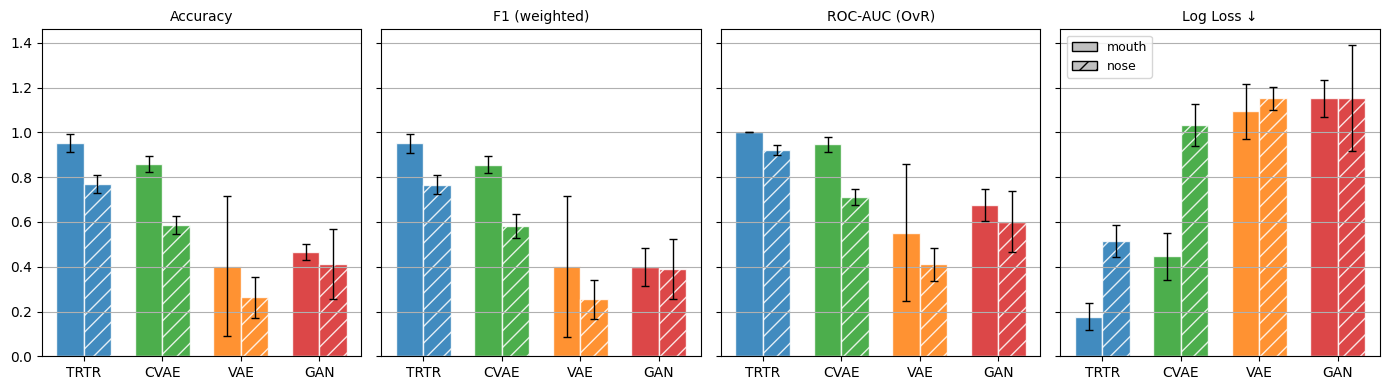

In [3]:
# load summary
df = pd.read_csv(f'{RESULT_DIR}/summary.csv')
df = df[df['free_bits'].isna() | (df['free_bits'] == 0.0)] # only include vanilla models, i.e. no free_bits
df['model'] = pd.Categorical(df['model'], categories=MODELS, ordered=True)
df = df.sort_values(['region', 'model', 'seed']).reset_index(drop=True)

# print summary
metrics_cols = ['accuracy', 'f1_weighted', 'roc_auc_ovr', 'log_loss', 'f1_bradypnea', 'f1_eupnea', 'f1_tachypnea', 'feature_overlap']
agg = df.groupby(['model', 'region'], observed=True)[metrics_cols].agg(['mean', 'std']).round(3)
rows = []
for (model, region), g in df.groupby(['model', 'region'], observed=True):
    row = {'model': model, 'region': region}
    for m in metrics_cols:
        mu = g[m].mean()
        sd = g[m].std()
        if pd.isna(sd) or len(g) < 2:
            row[m] = f'{mu:.3f}'
        else:
            row[m] = f'{mu:.3f} ± {sd:.3f}'
    rows.append(row)
summary = pd.DataFrame(rows)
summary['model'] = pd.Categorical(summary['model'], categories=MODELS, ordered=True)
summary = summary.sort_values(['region', 'model']).reset_index(drop=True)
print(summary.to_string(index=False))

# plot summary
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
axes = axes.flatten()
metrics_abs = ['accuracy', 'f1_weighted', 'roc_auc_ovr', 'log_loss']
metric_labels_abs = ['Accuracy', 'F1 (weighted)', 'ROC-AUC (OvR)', 'Log Loss ↓']
invert = [False, False, False, True]
x = np.arange(len(MODELS))
width = 0.35
hatch = {'mouth': '', 'nose': '//'}
for ax, m, label, inv in zip(axes, metrics_abs, metric_labels_abs, invert):
    for j, region in enumerate(REGIONS):
        means = [df[(df.model == mo) & (df.region == region)][m].mean() for mo in MODELS]
        stds  = [df[(df.model == mo) & (df.region == region)][m].std()  for mo in MODELS]
        bars = ax.bar(x + j * width, means, width, label=region, color=[MODEL_COLOR[mo] for mo in MODELS], hatch=hatch[region], alpha=0.85, edgecolor='white')
        ax.errorbar(x + j * width, means, yerr=stds, fmt='none', color='black', capsize=3, linewidth=1)
    ax.set_title(label)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([mo.upper() for mo in MODELS])
    ax.grid(axis='y')
    legend_patches = [mpatches.Patch(facecolor='silver', edgecolor='black', hatch=hatch[r], label=r) for r in REGIONS]
    ax.legend(handles=legend_patches, loc='upper left') if m == metrics_abs[3] else None

model_patches = [mpatches.Patch(facecolor=MODEL_COLOR[m], label=m.upper()) for m in MODELS]
plt.tight_layout()
plt.show()

## VAE

In [ ]:
# load vae models
models = {seed: {region: {} for region in REGIONS} for seed in SEEDS}
datasets = {seed: {} for seed in SEEDS}
splits = {seed: {} for seed in SEEDS}
FREE_BITS = [0.0, 0.1, 2.0]

for seed in SEEDS:
    for region in REGIONS:
        df = load_dataset()
        df = df[df["region"] == region].reset_index(drop=True)
        df_train, df_val, df_test = split_dataset(df, random_state=seed)
        train_ds = BreathDataset(df_train)
        datasets[seed][region] = {"train": train_ds,
                                  "val":   BreathDataset(df_val,  stats=train_ds.stats),
                                  "test":  BreathDataset(df_test, stats=train_ds.stats)}
        splits[seed][region] = {"train": df_train, "val": df_val, "test": df_test}

        for free_bit in FREE_BITS:
            ckpt_path = f'results/experiments/vae/{region}_s{seed}_fb{free_bit}_checkpoint.pt'
            ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
            model = VAE(latent_dim=ckpt['latent_dim']).to(device)
            model.load_state_dict(ckpt['model_state'])
            model.eval()
            models[seed][region][free_bit] = model

In [ ]:
rows = []
for free_bit in FREE_BITS:
    for region in REGIONS:
        accs = []
        for seed in SEEDS:
            path = f'results/experiments/vae/{region}_s{seed}_fb{free_bit}_tstr.json'
            with open(path) as f:
                accs.append(json.load(f)['metrics']['accuracy'])
        rows.append({'free_bits': free_bit,
                     'region': region,
                     'mean': round(np.mean(accs), 4),
                     'std': round(np.std(accs),  4),
                     'formatted': f"{np.mean(accs):.4f} ± {np.std(accs):.4f}"})

df_acc = pd.DataFrame(rows)
print(df_acc[['free_bits', 'region', 'formatted']].to_string(index=False))

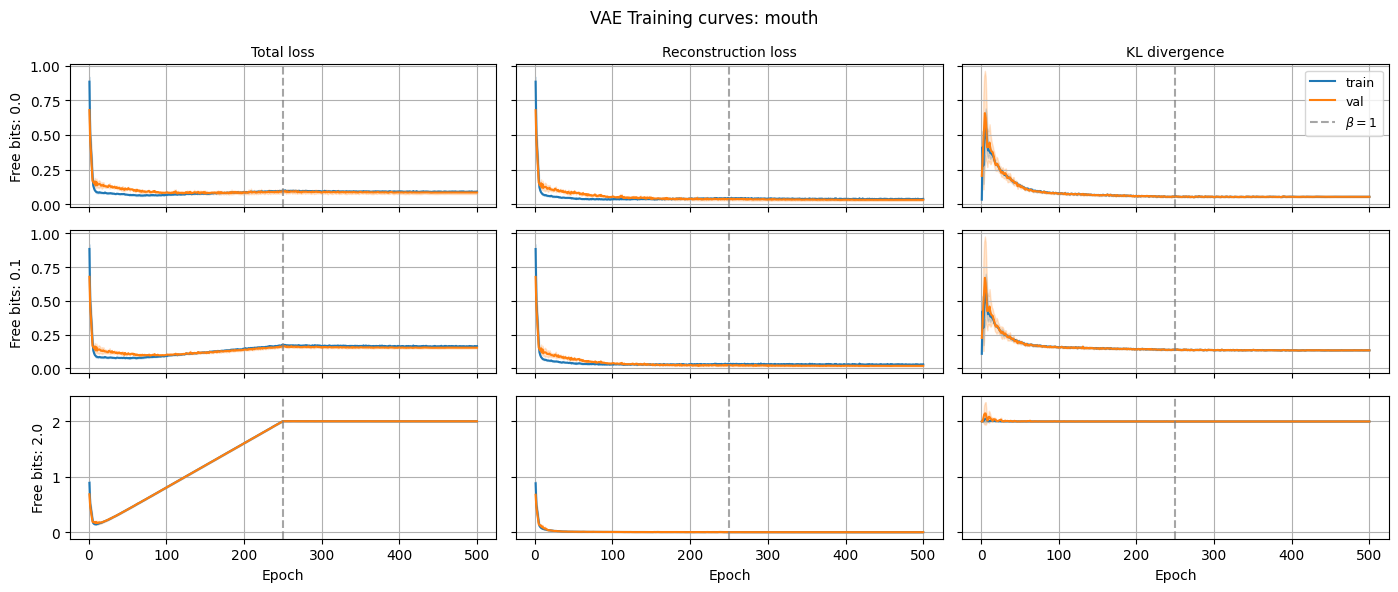

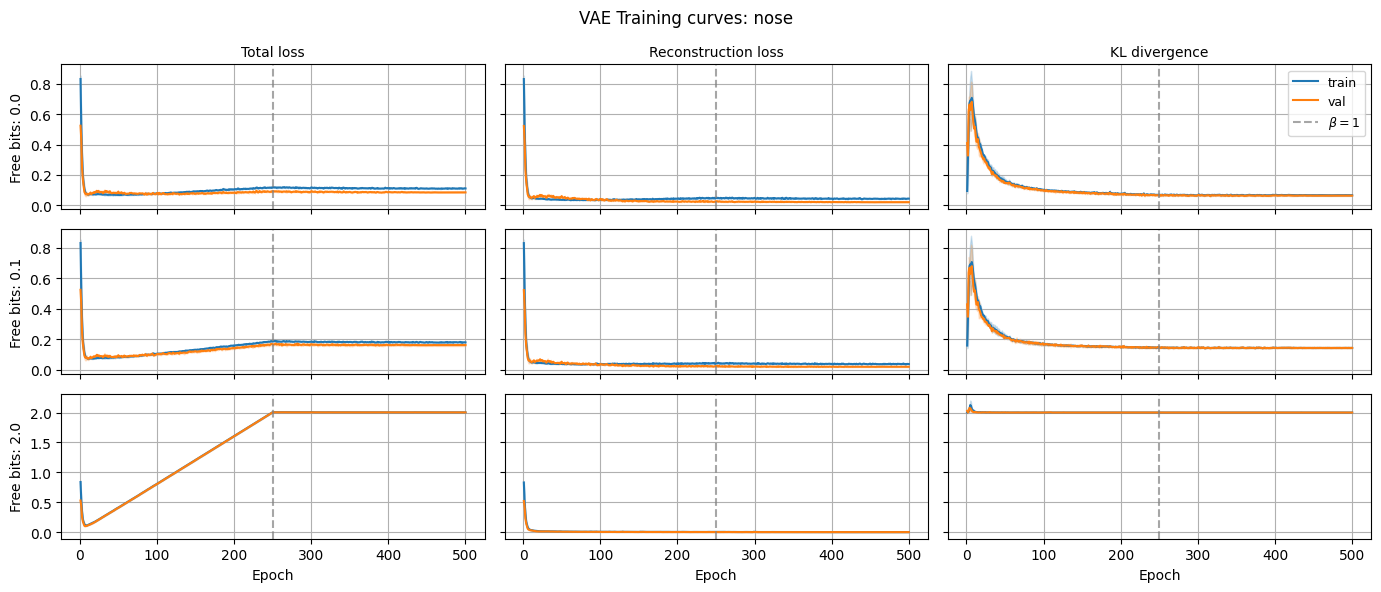

In [ ]:
# training curves
pairs = [('train_loss', 'val_loss', 'Total loss'),
         ('train_recon', 'val_recon', 'Reconstruction loss'),
         ('train_kl', 'val_kl', 'KL divergence')]

for region in REGIONS:
    n_configs = len(FREE_BITS)
    fig, axes = plt.subplots(n_configs, 3, figsize=(14, 6), sharey='row', sharex=True)
    fig.suptitle(f'VAE Training curves: {region}')

    for row, free_bit in enumerate(FREE_BITS):
        hists = [pd.read_csv(f'results/experiments/vae/{region}_s{seed}_fb{free_bit}_train_history.csv') for seed in SEEDS]
        epochs = hists[0]['epoch'].values
        beta_one_median = int(np.median([h.loc[h['beta'] >= 1.0, 'epoch'].min() for h in hists]))

        for col, (tr_col, vl_col, title) in enumerate(pairs):
            ax = axes[row, col]
            for data_col, label, color in [(tr_col, 'train', 'tab:blue'), (vl_col, 'val', 'tab:orange')]:
                vals = np.stack([h[data_col].values for h in hists])
                mean = vals.mean(axis=0)
                std  = vals.std(axis=0)
                ax.plot(epochs, mean, label=label, color=color)
                ax.fill_between(epochs, mean - std, mean + std, alpha=0.2, color=color)
            ax.axvline(beta_one_median, color='gray', linestyle='--', alpha=0.7, label=r'$\beta=1$')
            if row == 0:
                ax.set_title(title)
            if col == 0:
                ax.set_ylabel(f'Free bits: {free_bit}')
            if row == n_configs - 1:
                ax.set_xlabel('Epoch')
            ax.legend(loc='upper right') if (row, col) == (0, 2) else None
            ax.grid()

    plt.tight_layout()
    plt.show()

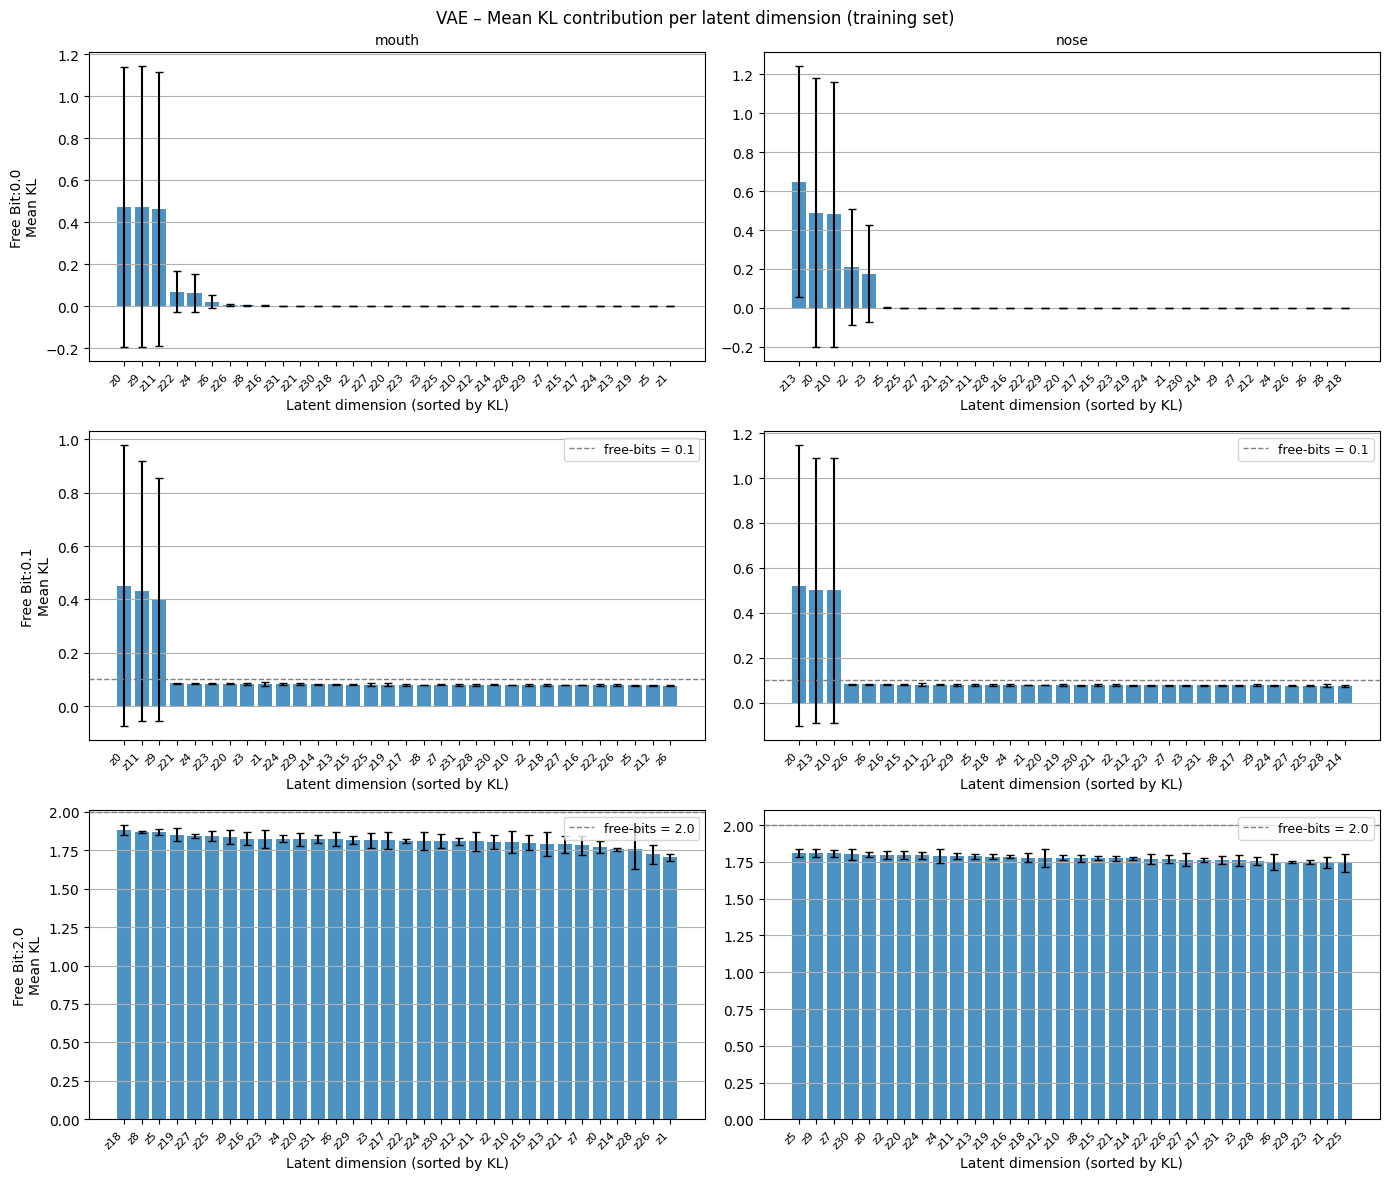

In [ ]:
# plot latent dimension activation
n_configs = len(FREE_BITS)
fig, axes = plt.subplots(n_configs, 2, figsize=(14, 4 * n_configs))
fig.suptitle('Mean KL contribution per latent dimension')

for row, free_bit in enumerate(FREE_BITS):
    for col, region in enumerate(REGIONS):
        ax = axes[row, col]
        kl_per_dim_seeds = []

        for seed in SEEDS:
            train_ds = datasets[seed][region]['train']
            model = models[seed][region][free_bit]
            model.eval()

            mus, logvars = [], []
            with torch.no_grad():
                for i in range(len(train_ds)):
                    signal, _, _ = train_ds[i]
                    mu, logvar = model.encoder(signal.unsqueeze(0).to(device))
                    mus.append(mu.squeeze(0).cpu())
                    logvars.append(logvar.squeeze(0).cpu())

            mus     = torch.stack(mus)
            logvars = torch.stack(logvars)
            kl_per_dim = (-0.5 * (1 + logvars - mus.pow(2) - logvars.exp())).mean(dim=0)
            kl_per_dim_seeds.append(kl_per_dim.numpy())

        kl_mean = np.mean(kl_per_dim_seeds, axis=0)
        kl_std = np.std(kl_per_dim_seeds,  axis=0)
        order = np.argsort(kl_mean)[::-1]
        x = np.arange(len(kl_mean))

        ax.bar(x, kl_mean[order], yerr=kl_std[order], capsize=3, color='tab:blue', alpha=0.8)
        if free_bit > 0:
            ax.axhline(free_bit, color='gray', linestyle='--', linewidth=1, label=f'free-bits = {free_bit}')
            ax.legend()
        ax.set_xticks(x)
        ax.set_xticklabels([f'z{i}' for i in order], rotation=45, ha='right', fontsize=8)
        ax.set_xlabel('Latent dimension (sorted by KL)')
        if row == 0:
            ax.set_title(region)
        if col == 0:
            ax.set_ylabel(f'Free Bit:{free_bit}\nMean KL')
        ax.grid(axis='y')

plt.tight_layout()
plt.show()

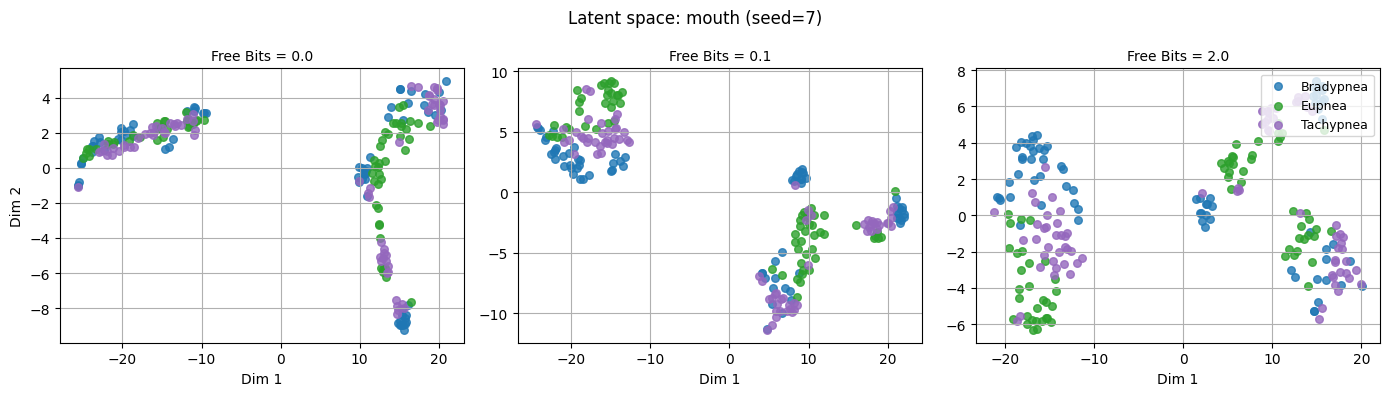

In [21]:
seed = SEEDS[0]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'Latent space: mouth (seed={seed})')

for col, free_bit in enumerate(FREE_BITS):
    ax = axes[col]
    train_ds = datasets[seed]['mouth']['train']
    model = models[seed]['mouth'][free_bit]
    model.eval()
    mus, labels = [], []
    with torch.no_grad():
        for i in range(len(train_ds)):
            signal, _, label = train_ds[i]
            mu, _ = model.encoder(signal.unsqueeze(0).to(device))
            mus.append(mu.squeeze(0).cpu().numpy())
            labels.append(label)
    mus    = np.stack(mus)
    labels = np.array(labels)
    z2d = TSNE(n_components=2, random_state=seed).fit_transform(mus)
    for i, cls in enumerate(CLASSES):
        mask = labels == i
        points = z2d[mask]
        ax.scatter(points[:, 0], points[:, 1], label=cls.capitalize(), alpha=0.8, color=CLASS_COLORS[cls], s=30)
    ax.set_title(f'Free Bits = {free_bit}')
    ax.set_xlabel('Dim 1')
    if col == 0:
        ax.set_ylabel('Dim 2')
    ax.legend(loc='upper right') if col == 2 else None
    ax.grid()
plt.tight_layout()
plt.show()

In [ ]:
# cosine similarity of samples
@torch.no_grad()
def mean_cosine_sim(model, n=100):
    samples = model.sample(n, device).cpu().numpy()
    flat = samples.reshape(n, -1)
    normed = normalize(flat)
    sim = normed @ normed.T
    mask = ~np.eye(n, dtype=bool)
    return float(sim[mask].mean())

rows = []
for free_bit in FREE_BITS:
    for region in REGIONS:
        sims = [mean_cosine_sim(models[seed][region][free_bit]) for seed in SEEDS]
        rows.append({'free_bits': free_bit,
                     'region': region,
                     'cosine_sim_mean': round(np.mean(sims), 4),
                     'cosine_sim_std': round(np.std(sims),  4),
                     'formatted': f"{np.mean(sims):.4f} ± {np.std(sims):.4f}"})

df_cos = pd.DataFrame(rows)
print(df_cos[['free_bits', 'region', 'formatted']].to_string(index=False))

 free_bits region       formatted
       0.0  mouth 0.6628 ± 0.0070
       0.0   nose 0.5517 ± 0.0303
       0.1  mouth 0.6992 ± 0.0109
       0.1   nose 0.5948 ± 0.0191
       2.0  mouth 0.9187 ± 0.0099
       2.0   nose 0.8545 ± 0.0126


### CVAE

In [ ]:
models = {seed: {} for seed in SEEDS}
datasets = {seed: {} for seed in SEEDS}
splits = {seed: {} for seed in SEEDS}

for seed in SEEDS:
    for region in REGIONS:
        # load dataset
        df = load_dataset()
        df = df[df["region"] == region].reset_index(drop=True)
        df_train, df_val, df_test = split_dataset(df, random_state=seed)

        # datasets
        train_ds = BreathDataset(df_train)
        val_ds = BreathDataset(df_val,  stats=train_ds.stats)
        test_ds = BreathDataset(df_test, stats=train_ds.stats)
        datasets[seed][region] = {"train": train_ds, "val": val_ds, "test": test_ds}
        splits[seed][region] = {"train": df_train, "val": df_val, "test": df_test}

        # model
        ckpt_path = f"models/checkpoints/cvae_{region}_s{seed}.pt"
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        model = CVAE(latent_dim=ckpt['latent_dim'], embed_dim=ckpt['embed_dim']).to(device)
        model.load_state_dict(ckpt['model_state'])
        model.eval()
        models[seed][region] = model

In [ ]:
pairs = [('train_loss',  'val_loss',  'Total loss'),
         ('train_recon', 'val_recon', 'Reconstruction loss'),
         ('train_kl',    'val_kl',    'KL divergence')]

for region in REGIONS:
    hists = [pd.read_csv(f'results/cvae/train_{region}_s{seed}.csv') for seed in SEEDS]
    epochs = hists[0]['epoch'].values
    beta1_med = int(np.median([h.loc[h['beta'] >= 1.0, 'epoch'].min() for h in hists]))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f'CVAE Training curves: {region}')

    for ax, (tr_col, vl_col, title) in zip(axes, pairs):
        for col, label, color in [(tr_col, 'train', 'tab:blue'), (vl_col, 'val', 'tab:orange')]:
            vals = np.stack([h[col].values for h in hists])  # (n_seeds, n_epochs)
            mean = vals.mean(axis=0)
            std  = vals.std(axis=0)
            ax.plot(epochs, mean, label=label, color=color)
            ax.fill_between(epochs, mean - std, mean + std, alpha=0.2, color=color)
        ax.axvline(beta1_med, color='gray', linestyle='--', alpha=0.7, label=r'$\beta=1$')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid()

    plt.tight_layout()
    plt.show()

In [ ]:
for seed in SEEDS:
    for region in REGIONS:
        train_ds = datasets[seed][region]['train']
        model = models[seed][region]
        model.eval()

        # denormalization
        mean = train_ds.stats['mean'][:, None]
        std  = train_ds.stats['std'][:, None]
        def denorm(x):
            return x * std + mean

        fig, axes = plt.subplots(2, 3, figsize=(14, 4), sharex=True, sharey='row')
        fig.suptitle(f'CVAE Reconstruction: {region}')

        # sample 3 signals from train_ds
        sample_indices = np.random.default_rng(42).choice(len(train_ds), size=3, replace=False)
        for col, idx in enumerate(sample_indices):
            signal, time, label = train_ds[idx]
            signal_batch = signal.unsqueeze(0).to(device)
            label_t = torch.tensor([label]).long().to(device)
            with torch.no_grad():
                x_hat, _, _ = model(signal_batch, label_t)
            x_hat      = denorm(x_hat.squeeze(0).cpu().numpy())
            signal_np  = denorm(signal.numpy())
            time_np    = time.numpy()

            for row in range(2):
                ax = axes[row, col]
                ax.plot(time_np, signal_np[row], label='real', color='tab:blue')
                ax.plot(time_np, x_hat[row], label='reconstruction', color='tab:orange', linestyle='--')
                ax.grid()
                axes[row, 0].set_ylabel(CHANNEL_NAMES[row])
                axes[0, col].set_title(f'Sample {idx} ({CLASSES[label]})')
                axes[0, 0].legend(loc='upper left')
                axes[-1, col].set_xlabel('Time in s')
        plt.tight_layout()
        plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(7, 4), sharey=True)
plt.suptitle('Reconstruction MSE per class')

for region_idx, region in enumerate(REGIONS):
    # collect per-seed mean MSE per class, then aggregate across seeds
    seed_means = {i: [] for i in range(len(CLASSES))}
    for seed in SEEDS:
        test_ds = datasets[seed][region]['test']
        model = models[seed][region]
        model.eval()
        mse_per_class = {i: [] for i in range(len(CLASSES))}
        with torch.no_grad():
            for i in range(len(test_ds)):
                signal, _, label = test_ds[i]
                label_t = torch.tensor([label]).long().to(device)
                x_hat, _, _ = model(signal.unsqueeze(0).to(device), label_t)
                mse = (x_hat.squeeze(0) - signal.to(device)).pow(2).mean().item()
                mse_per_class[label].append(mse)
        for cls_idx in range(len(CLASSES)):
            seed_means[cls_idx].append(np.mean(mse_per_class[cls_idx]))

    means = [np.mean(seed_means[i]) for i in range(len(CLASSES))]
    stds  = [np.std(seed_means[i])  for i in range(len(CLASSES))]

    axes[region_idx].bar(CLASSES, means, yerr=stds, capsize=5, color=list(CLASS_COLORS.values()))
    axes[region_idx].set_ylabel('MSE (normalized)') if region_idx == 0 else None
    axes[region_idx].set_title(f'Test set: {region}')
    axes[region_idx].grid(axis='y')

plt.tight_layout()
plt.show()

In [ ]:
for seed in SEEDS:
    fig, axes = plt.subplots(3, 2, figsize=(10, 12))
    plt.suptitle('Latent space projections')

    methods = [
        ('PCA',   lambda z: PCA(n_components=2).fit_transform(z)),
        ('t-SNE', lambda z: TSNE(n_components=2, random_state=42).fit_transform(z)),
        ('UMAP',  lambda z: umap.UMAP(n_components=4, random_state=42, n_jobs=1).fit_transform(z)),
    ]

    for col, region in enumerate(REGIONS):
        train_ds = datasets[seed][region]['train']
        model = models[seed][region]
        model.eval()

        mus, labels = [], []
        with torch.no_grad():
            for i in range(len(train_ds)):
                signal, _, label = train_ds[i]
                mu, _ = model.encoder(signal.unsqueeze(0).to(device),
                                    torch.tensor([label]).long().to(device))
                mus.append(mu.squeeze(0).cpu().numpy())
                labels.append(label)
        mus    = np.stack(mus)
        labels = np.array(labels)

        for row, (method_name, project) in enumerate(methods):
            z2d = project(mus)
            ax  = axes[row, col]
            for i, cls in enumerate(CLASSES):
                mask = labels == i
                ax.scatter(z2d[mask, 0], z2d[mask, 1], label=cls.capitalize(), alpha=0.8)
            if row == 0:
                ax.set_title(region)
            if col == 0:
                ax.set_ylabel(method_name, fontsize=11, fontweight='bold')
            ax.set_xlabel('Dim 1')
            ax.legend(loc='upper right')
            ax.grid()

    plt.tight_layout()
    plt.show()


In [ ]:
for seed in SEEDS:
    for region in REGIONS:
        train_ds = datasets[seed][region]['train']
        model = models[seed][region]
        model.eval()

        mean = train_ds.stats['mean'][:, None]
        std  = train_ds.stats['std'][:, None]
        def denorm(x):
            return x * std + mean

        time_np = train_ds[0][1].numpy()

        fig, axes = plt.subplots(3, 3, figsize=(14, 6), sharex=True, sharey=False)
        fig.suptitle(f'CVAE Generated Samples: {region}')

        for col, (cls, cls_idx) in enumerate(zip(CLASSES, range(len(CLASSES)))):
            samples = denorm(model.sample(3, torch.tensor(cls_idx).long(), device).cpu().numpy())
            for row in range(3):
                ax = axes[row, col]
                ax.plot(time_np, samples[row, 0], color='tab:blue')
                ax.grid()
                ax_r = ax.twinx()
                ax_r.plot(time_np, samples[row, 1], color='tab:orange')
                if row == 0:
                    ax.set_title(f'{cls.capitalize()}')
                if col == 0:
                    ax.set_ylabel(f'\n{CHANNEL_NAMES[0]}', color='tab:blue')
                    ax.tick_params(axis='y', colors='tab:blue')
                else:
                    ax.set_yticklabels([])
                    ax.tick_params(axis='y', length=0)
                if col == 2:
                    ax_r.set_ylabel(CHANNEL_NAMES[1], color='tab:orange')
                    ax_r.tick_params(axis='y', colors='tab:orange')
                else:
                    ax_r.set_yticklabels([])
                    ax_r.tick_params(axis='y', length=0)
                if row == 2:
                    ax.set_xlabel('Time in s')

        plt.tight_layout()
        plt.show()


In [ ]:
!jupyter nbconvert tstr.ipynb --to pdf --TagRemovePreprocessor.enabled=True --TagRemovePreprocessor.remove_cell_tags='{"remove_cell"}'